In [19]:
# Cell 1: 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import json
import ast

# 设置中文显示和样式
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
sns.set_style("whitegrid")

# 设置路径
PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "goemotions"

print("✅ 库导入成功！")
print(f"数据路径: {DATA_DIR}")

✅ 库导入成功！
数据路径: d:\BaiduSyncdisk\大学学习文件\大二寒假实训\泰康保险\emotion-recognition\data\raw\goemotions


In [20]:
# Cell 2: 加载数据集
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("数据集加载完成！")
print(f"训练集: {len(train_df)} 条")
print(f"验证集: {len(val_df)} 条")
print(f"测试集: {len(test_df)} 条")
print(f"总计: {len(train_df) + len(val_df) + len(test_df)} 条")

数据集加载完成！
训练集: 43410 条
验证集: 5426 条
测试集: 5427 条
总计: 54263 条


In [21]:
# Cell 3: 查看数据结构
print("=" * 50)
print("数据集列名:")
print(train_df.columns.tolist())
print("\n" + "=" * 50)
print("前5条数据:")
display(train_df.head())

print("\n" + "=" * 50)
print("数据类型:")
print(train_df.dtypes)

# 注意：labels列是object类型，实际是字符串形式的列表
print("\n" + "=" * 50)
print("labels列样例（前3条）:")
for i in range(3):
    print(f"  {i}: {train_df['labels'].iloc[i]} (类型: {type(train_df['labels'].iloc[i])})")

数据集列名:
['text', 'labels', 'id']

前5条数据:


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj



数据类型:
text      object
labels    object
id        object
dtype: object

labels列样例（前3条）:
  0: [27] (类型: <class 'str'>)
  1: [27] (类型: <class 'str'>)
  2: [2] (类型: <class 'str'>)


In [22]:
# Cell 4: 解析labels列
# labels列是字符串格式的列表，需要转换为真正的列表
def parse_labels(label_str):
    """将字符串形式的列表转换为真正的列表"""
    try:
        return ast.literal_eval(label_str)
    except:
        return []

train_df['labels'] = train_df['labels'].apply(parse_labels)
val_df['labels'] = val_df['labels'].apply(parse_labels)
test_df['labels'] = test_df['labels'].apply(parse_labels)

print("✅ labels列已转换为列表格式")
print(f"转换后样例: {train_df['labels'].iloc[0]}")

✅ labels列已转换为列表格式
转换后样例: [27]


In [23]:
# Cell 5: 检查缺失值
print("=" * 50)
print("缺失值统计:")
print(train_df.isnull().sum())

# 检查空的labels
empty_labels = (train_df['labels'].apply(len) == 0).sum()
print(f"\n空标签数量: {empty_labels}")

缺失值统计:
text      0
labels    0
id        0
dtype: int64

空标签数量: 0


C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1754302560.py:26: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1754302560.py:26: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1754302560.py:26: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1754302560.py:26: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1754302560.py:26: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1754302560.py:26: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font

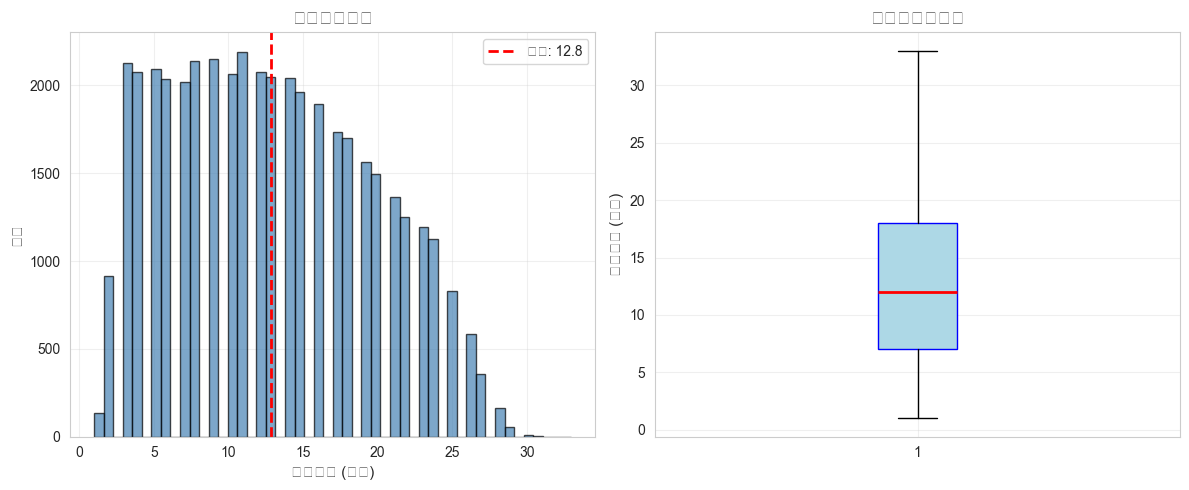

文本长度统计:
  平均长度: 12.84 词
  最短: 1 词
  最长: 33 词
  中位数: 12.00 词
  75分位数: 18.00 词


In [24]:
# Cell 6: 文本长度分析
train_df['text_length'] = train_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))

# 文本长度分布
plt.subplot(1, 2, 1)
plt.hist(train_df['text_length'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('文本长度 (词数)', fontsize=11)
plt.ylabel('频数', fontsize=11)
plt.title('文本长度分布', fontsize=13, fontweight='bold')
plt.axvline(train_df['text_length'].mean(), color='red', linestyle='--', 
            label=f'平均: {train_df["text_length"].mean():.1f}', linewidth=2)
plt.legend()
plt.grid(alpha=0.3)

# 箱线图
plt.subplot(1, 2, 2)
plt.boxplot(train_df['text_length'], patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2))
plt.ylabel('文本长度 (词数)', fontsize=11)
plt.title('文本长度箱线图', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"文本长度统计:")
print(f"  平均长度: {train_df['text_length'].mean():.2f} 词")
print(f"  最短: {train_df['text_length'].min()} 词")
print(f"  最长: {train_df['text_length'].max()} 词")
print(f"  中位数: {train_df['text_length'].median():.2f} 词")
print(f"  75分位数: {train_df['text_length'].quantile(0.75):.2f} 词")

In [25]:
# Cell 7: 情绪标签分析
print("=" * 50)
print("情绪标签分析:")
print("=" * 50)

# GoEmotions标准标签映射（28种情绪）
GOEMOTIONS_LABELS = {
    0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance',
    4: 'approval', 5: 'caring', 6: 'confusion', 7: 'curiosity',
    8: 'desire', 9: 'disappointment', 10: 'disapproval', 11: 'disgust',
    12: 'embarrassment', 13: 'excitement', 14: 'fear', 15: 'gratitude',
    16: 'grief', 17: 'joy', 18: 'love', 19: 'nervousness',
    20: 'optimism', 21: 'pride', 22: 'realization', 23: 'relief',
    24: 'remorse', 25: 'sadness', 26: 'surprise', 27: 'neutral'
}

# 统计所有标签
all_labels = []
for labels in train_df['labels']:
    all_labels.extend(labels)

label_counts = Counter(all_labels)
label_counts_sorted = dict(sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

print(f"共发现 {len(label_counts_sorted)} 种不同的情绪标签")
print(f"总标签数（包含重复）: {len(all_labels):,}")

print("\n各情绪标签频次（Top 20）:")
for i, (label_id, count) in enumerate(list(label_counts_sorted.items())[:20], 1):
    emotion_name = GOEMOTIONS_LABELS.get(label_id, f"未知_{label_id}")
    percentage = (count / len(train_df) * 100)
    print(f"{i:2d}. [{label_id:2d}] {emotion_name:20s}: {count:6,} ({percentage:5.2f}%)")

# 保存标签映射
label_mapping_path = PROJECT_ROOT / "data" / "label_mapping.json"
with open(label_mapping_path, 'w', encoding='utf-8') as f:
    json.dump(GOEMOTIONS_LABELS, f, indent=2, ensure_ascii=False)
print(f"\n✅ 标签映射已保存至: {label_mapping_path}")

情绪标签分析:
共发现 28 种不同的情绪标签
总标签数（包含重复）: 51,103

各情绪标签频次（Top 20）:
 1. [27] neutral             : 14,219 (32.76%)
 2. [ 0] admiration          :  4,130 ( 9.51%)
 3. [ 4] approval            :  2,939 ( 6.77%)
 4. [15] gratitude           :  2,662 ( 6.13%)
 5. [ 3] annoyance           :  2,470 ( 5.69%)
 6. [ 1] amusement           :  2,328 ( 5.36%)
 7. [ 7] curiosity           :  2,191 ( 5.05%)
 8. [18] love                :  2,086 ( 4.81%)
 9. [10] disapproval         :  2,022 ( 4.66%)
10. [20] optimism            :  1,581 ( 3.64%)
11. [ 2] anger               :  1,567 ( 3.61%)
12. [17] joy                 :  1,452 ( 3.34%)
13. [ 6] confusion           :  1,368 ( 3.15%)
14. [25] sadness             :  1,326 ( 3.05%)
15. [ 9] disappointment      :  1,269 ( 2.92%)
16. [22] realization         :  1,110 ( 2.56%)
17. [ 5] caring              :  1,087 ( 2.50%)
18. [26] surprise            :  1,060 ( 2.44%)
19. [13] excitement          :    853 ( 1.96%)
20. [11] disgust             :    793 ( 1.83%)

C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\344184812.py:22: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\344184812.py:22: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\344184812.py:22: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\344184812.py:22: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\344184812.py:22: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\344184812.py:22: UserWarning: Glyph 32490 (\N{CJK UNIFIED IDEOGRAPH-7EEA}) missing from font(s) Ar

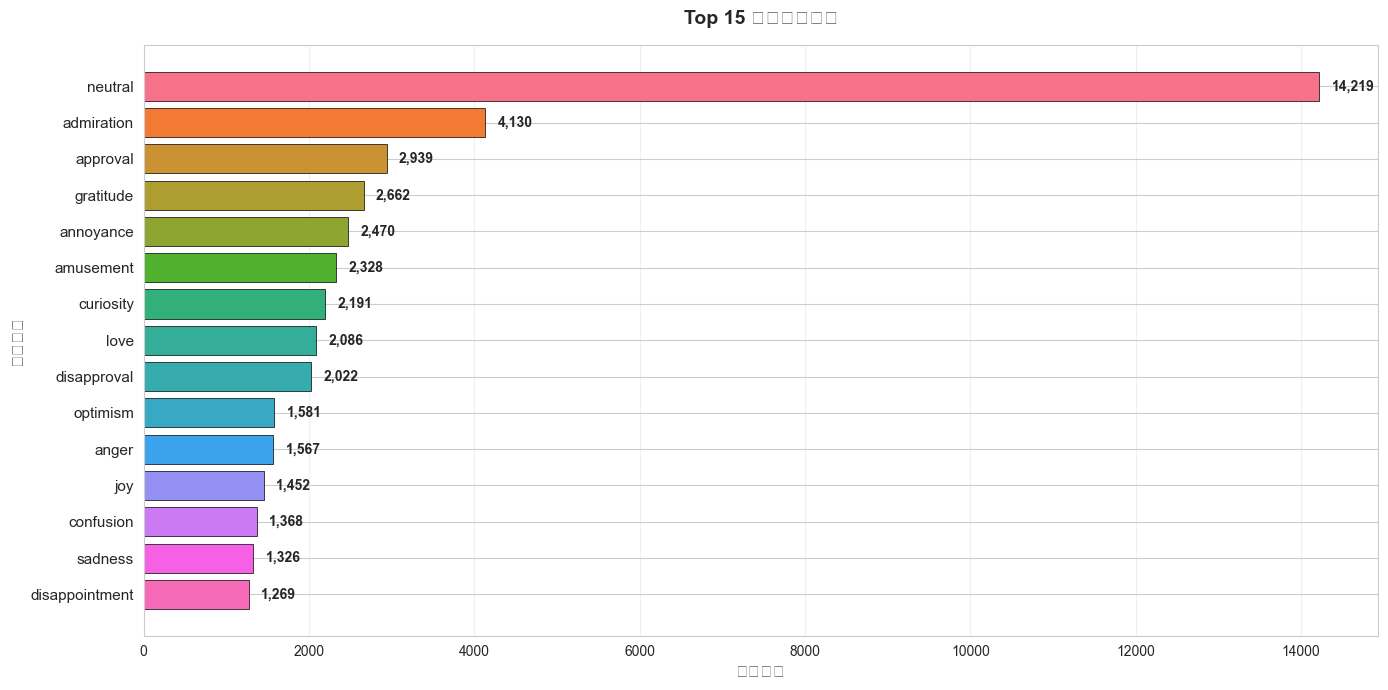

✅ 可视化完成


In [26]:
# Cell 8: 可视化情绪分布
# 取前15个最常见的情绪
top_15 = list(label_counts_sorted.items())[:15]
label_ids = [x[0] for x in top_15]
counts = [x[1] for x in top_15]
emotion_names = [GOEMOTIONS_LABELS.get(lid, f"未知_{lid}") for lid in label_ids]

plt.figure(figsize=(14, 7))
colors = sns.color_palette("husl", 15)
bars = plt.barh(range(len(emotion_names)), counts, color=colors, edgecolor='black', linewidth=0.5)
plt.yticks(range(len(emotion_names)), emotion_names, fontsize=11)
plt.xlabel('样本数量', fontsize=12)
plt.ylabel('情绪标签', fontsize=12)
plt.title('Top 15 情绪标签分布', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()

# 在柱状图上添加数值
for i, (bar, count) in enumerate(zip(bars, counts)):
    plt.text(count + 150, i, f'{count:,}', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✅ 可视化完成")

C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1618104130.py:22: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1618104130.py:22: UserWarning: Glyph 26465 (\N{CJK UNIFIED IDEOGRAPH-6761}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1618104130.py:22: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1618104130.py:22: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1618104130.py:22: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\宗家锐\AppData\Local\Temp\ipykernel_5168\1618104130.py:22: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font

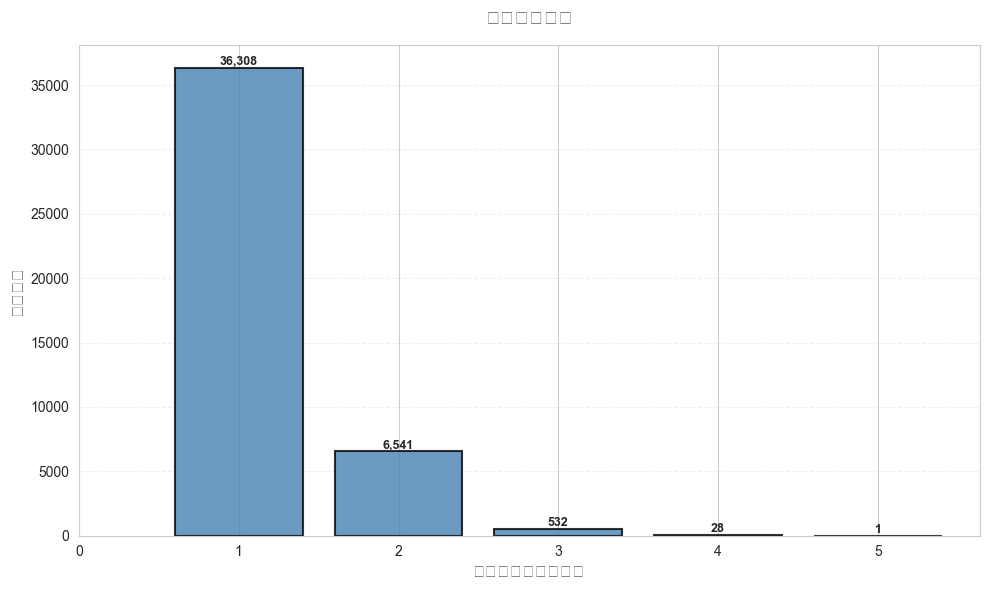

标签数量统计:
  平均每条样本有 1.18 个标签
  最少: 1 个
  最多: 5 个

详细分布:
 标签数   样本数    占比
   1 36308 83.64
   2  6541 15.07
   3   532  1.23
   4    28  0.06
   5     1  0.00

单标签样本: 36,308 (83.64%)
多标签样本: 7,102 (16.36%)


In [27]:
# Cell 9: 多标签统计
# 统计每条样本有多少个标签
train_df['num_labels'] = train_df['labels'].apply(len)

plt.figure(figsize=(10, 6))
label_dist = train_df['num_labels'].value_counts().sort_index()
bars = plt.bar(label_dist.index, label_dist.values, edgecolor='black', 
               alpha=0.8, color='steelblue', linewidth=1.5)
plt.xlabel('每条样本的标签数量', fontsize=12)
plt.ylabel('样本数量', fontsize=12)
plt.title('标签数量分布', fontsize=14, fontweight='bold', pad=15)
plt.xticks(range(0, int(train_df['num_labels'].max()) + 1))
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("标签数量统计:")
print(f"  平均每条样本有 {train_df['num_labels'].mean():.2f} 个标签")
print(f"  最少: {train_df['num_labels'].min()} 个")
print(f"  最多: {train_df['num_labels'].max()} 个")

print(f"\n详细分布:")
dist_df = pd.DataFrame({
    '标签数': label_dist.index,
    '样本数': label_dist.values,
    '占比': (label_dist.values / len(train_df) * 100).round(2)
})
print(dist_df.to_string(index=False))

# 统计单标签vs多标签
single_label = (train_df['num_labels'] == 1).sum()
multi_label = (train_df['num_labels'] > 1).sum()
print(f"\n单标签样本: {single_label:,} ({single_label/len(train_df)*100:.2f}%)")
print(f"多标签样本: {multi_label:,} ({multi_label/len(train_df)*100:.2f}%)")

In [28]:
# Cell 10: 查看样本数据
print("=" * 70)
print("随机样本展示:")
print("=" * 70)

# 随机选择5条数据
np.random.seed(42)  # 固定随机种子以便复现
samples = train_df.sample(5)

for idx, row in samples.iterrows():
    print(f"\n📝 样本 #{idx}:")
    text = row['text']
    if len(text) > 100:
        print(f"   文本: {text[:100]}...")
    else:
        print(f"   文本: {text}")
    
    print(f"   长度: {row['text_length']} 词")
    
    # 解析情绪标签
    label_ids = row['labels']
    emotions = [GOEMOTIONS_LABELS.get(lid, f"未知_{lid}") for lid in label_ids]
    print(f"   标签ID: {label_ids}")
    print(f"   情绪: {', '.join(emotions)}")
    print("-" * 70)

随机样本展示:

📝 样本 #25759:
   文本: The only way this works is if [NAME] is doing the Bird Box challenge and cant see the terms of the c...
   长度: 22 词
   标签ID: [27]
   情绪: neutral
----------------------------------------------------------------------

📝 样本 #22531:
   文本: Access should be hindered it's getting destroyed.
   长度: 7 词
   标签ID: [3]
   情绪: annoyance
----------------------------------------------------------------------

📝 样本 #18418:
   文本: Totally fair. All I was trying to remind everyone is don't fall in love with your crushes.
   长度: 17 词
   标签ID: [4]
   情绪: approval
----------------------------------------------------------------------

📝 样本 #31117:
   文本: I'm poly and jn the Raleigh area too, moved here for my wife's job, surprised to find so many people...
   长度: 23 词
   标签ID: [26]
   情绪: surprise
----------------------------------------------------------------------

📝 样本 #5733:
   文本: Naw man Asain men have an easier time. Most of my asain friend are pretty boy. Fuckbois lo

In [29]:
# Cell 11: 生成数据探索总结
summary = f"""
{'=' * 70}
                    GoEmotions 数据探索总结报告
{'=' * 70}

1. 数据集规模:
   - 训练集: {len(train_df):,} 条
   - 验证集: {len(val_df):,} 条
   - 测试集: {len(test_df):,} 条
   - 总计: {len(train_df) + len(val_df) + len(test_df):,} 条

2. 文本特征:
   - 平均长度: {train_df['text_length'].mean():.2f} 词
   - 长度范围: {train_df['text_length'].min()} - {train_df['text_length'].max()} 词
   - 中位数长度: {train_df['text_length'].median():.2f} 词

3. 情绪标签:
   - 总标签种类: {len(label_counts_sorted)} 种
   - 单标签样本: {(train_df['num_labels'] == 1).sum():,} 条 ({(train_df['num_labels'] == 1).sum() / len(train_df) * 100:.2f}%)
   - 多标签样本: {(train_df['num_labels'] > 1).sum():,} 条 ({(train_df['num_labels'] > 1).sum() / len(train_df) * 100:.2f}%)
   - 平均标签数: {train_df['num_labels'].mean():.2f} 个/样本

4. 最常见的5种情绪:
"""

for i, (label_id, count) in enumerate(list(label_counts_sorted.items())[:5], 1):
    emotion_name = GOEMOTIONS_LABELS.get(label_id, f"未知_{label_id}")
    percentage = (count / len(train_df) * 100)
    summary += f"   {i}. {emotion_name}: {count:,} ({percentage:.2f}%)\n"

summary += f"""
5. 数据质量:
   - 缺失值: {'存在' if train_df.isnull().sum().sum() > 0 else '无'}
   - 空标签: {(train_df['num_labels'] == 0).sum()} 条
   - 数据完整性: 良好
   - 标签格式: 多标签分类（列表格式）

6. 下一步计划:
   ✓ 标签映射已创建: data/label_mapping.json
   ⏩ 数据预处理: 文本清洗、标准化
   ⏩ 数据增强: 回译、同义词替换等
   ⏩ 数据加载器: PyTorch DataLoader

{'=' * 70}
生成时间: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'=' * 70}
"""

print(summary)

# 保存总结到文件
summary_path = PROJECT_ROOT / "docs" / "data_exploration_summary.txt"
summary_path.parent.mkdir(exist_ok=True)
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary)
    
print(f"\n✅ 总结已保存至: {summary_path}")
print(f"\n🎉 数据探索完成！现在可以开始编写预处理脚本了。")


                    GoEmotions 数据探索总结报告

1. 数据集规模:
   - 训练集: 43,410 条
   - 验证集: 5,426 条
   - 测试集: 5,427 条
   - 总计: 54,263 条

2. 文本特征:
   - 平均长度: 12.84 词
   - 长度范围: 1 - 33 词
   - 中位数长度: 12.00 词

3. 情绪标签:
   - 总标签种类: 28 种
   - 单标签样本: 36,308 条 (83.64%)
   - 多标签样本: 7,102 条 (16.36%)
   - 平均标签数: 1.18 个/样本

4. 最常见的5种情绪:
   1. neutral: 14,219 (32.76%)
   2. admiration: 4,130 (9.51%)
   3. approval: 2,939 (6.77%)
   4. gratitude: 2,662 (6.13%)
   5. annoyance: 2,470 (5.69%)

5. 数据质量:
   - 缺失值: 无
   - 空标签: 0 条
   - 数据完整性: 良好
   - 标签格式: 多标签分类（列表格式）

6. 下一步计划:
   ✓ 标签映射已创建: data/label_mapping.json
   ⏩ 数据预处理: 文本清洗、标准化
   ⏩ 数据增强: 回译、同义词替换等
   ⏩ 数据加载器: PyTorch DataLoader

生成时间: 2026-02-14 11:12:50


✅ 总结已保存至: d:\BaiduSyncdisk\大学学习文件\大二寒假实训\泰康保险\emotion-recognition\docs\data_exploration_summary.txt

🎉 数据探索完成！现在可以开始编写预处理脚本了。
